# Hydro Linear Profiles

Notebook for comparing simulation profiles against the linear model.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import interpolate

plt.rcParams.update({"font.size": 18})


# Fiducial setup
CS = 0.02
ALPHA0 = 1e-3
SIGMA0 = 1.0

R_MIN, R_MAX = 0.5, 3.0
R_GAP_IN, R_GAP_OUT = 1.0, 2.0
D_EDGE_IN, D_EDGE_OUT = 0.10, 0.20
GAP_DEPTH = 19.0

SNAPSHOT_LIST = [
    "sim002t-const-alpha-t000.000",
    "sim002t-const-alpha-t251.201",
    "sim002-const-alpha-t1256.001",
]


def omega_k(r):
    return r**(-1.5)


def hdisk(r, cs=CS):
    return cs * r**0.5


def hdisk_abs(r, cs=CS):
    return cs * r**1.5


def gap_shape(r, gap_depth=GAP_DEPTH):
    return 1 + 0.5 * (gap_depth - 1) * (
        np.tanh((r - R_GAP_IN) / D_EDGE_IN)
        - np.tanh((r - R_GAP_OUT) / D_EDGE_OUT)
    )


def alpha_profile(r, alpha0=ALPHA0):
    return np.zeros_like(np.asarray(r)) + alpha0 * gap_shape(1.5)


def load_snapshot(name, data_dir="../data"):
    path = f"{data_dir}/{name}-res.npy"
    return np.load(path, allow_pickle=True).item()


def build_background_functions(snapshot):
    r_sim = snapshot["profiles"]["rad_app"]
    sigma_sim = snapshot["profiles"]["Sigma"]
    omega_sim = snapshot["profiles"]["Omega"]

    def sigma(r):
        return np.interp(r, r_sim, sigma_sim)

    def omega(r):
        return np.interp(r, r_sim, omega_sim)

    r_temp = np.linspace(R_MIN * 0.5, R_MAX * 1.1, 1001)
    kappa2_interp = interpolate.interp1d(
        r_temp,
        np.gradient(omega(r_temp) ** 2 * r_temp**4, r_temp) / r_temp**3,
        bounds_error=False,
        fill_value="extrapolate",
    )

    def epsilon(r):
        return np.zeros_like(np.asarray(r)) + kappa2_interp(r) / omega(r) ** 2 - 1

    return sigma, omega, kappa2_interp, epsilon


def solve_linear_model(snapshot, w_in=0.0, w_out=1.0, w_sim=0.033333):
    sigma, omega, kappa2, epsilon = build_background_functions(snapshot)

    def rhs(radius, y):
        W, G = y

        Sigma = sigma(radius)
        alp = alpha_profile(radius)
        h = hdisk(radius)
        H = hdisk_abs(radius)
        Ome = omega(radius)
        eps = epsilon(radius)

        dW_dR = -2 * (1j * eps + 2 * alp) / (1 + 2j * alp) * G / (
            Sigma * H**2 * radius**3 * Ome**2
        )
        dG_dR = -0.25 * Sigma * H * radius**3 * Ome**2 * alp * h * dW_dR + 1.5j * alp / radius * G
        return [dW_dR, dG_dR]

    sol = solve_ivp(rhs, [R_MIN, R_MAX], [w_in, 1 + 0j], rtol=1e-9, dense_output=True)

    r_plot = np.linspace(R_MIN, R_MAX, 101)
    W = sol.sol(r_plot)[0, :]
    G = sol.sol(r_plot)[1, :]

    scale = W[-1] / w_out
    W /= scale
    G /= scale

    W *= w_sim
    G *= w_sim

    return {"r": r_plot, "W": W, "G": G}


def extract_simulation_profiles(snapshot):
    r = snapshot["profiles"]["rad_app"]
    l_hat = snapshot["vectors"]["l_hat"]
    sigma = snapshot["profiles"]["Sigma"]
    time = snapshot["profiles"]["t"]

    W = l_hat[0, :] - 1j * l_hat[1, :]
    beta = np.abs(W)
    gamma = np.angle(W)
    psi = np.abs(np.gradient(W, r)) * r

    return {"r": r, "Sigma": sigma, "W": W, "beta": beta, "gamma": gamma, "psi": psi, "t": time}

In [2]:
snapshots = [load_snapshot(name) for name in SNAPSHOT_LIST]
theory_results = [solve_linear_model(snapshot) for snapshot in snapshots]
sim_results = [extract_simulation_profiles(snapshot) for snapshot in snapshots]

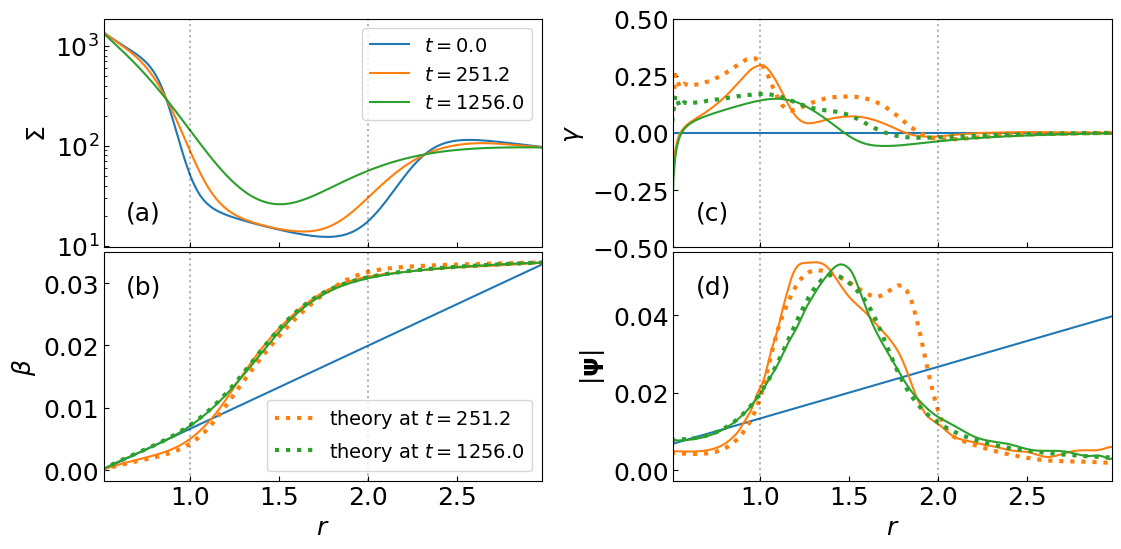

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
fig.subplots_adjust(wspace=0.30, hspace=0.02)

colors = [f"C{i}" for i in range(len(SNAPSHOT_LIST))]

for i, (snapshot, sim, theory) in enumerate(zip(snapshots, sim_results, theory_results)):
    color = colors[i]
    params = snapshot["params"]

    axs[0, 0].semilogy(sim["r"], sim["Sigma"], color=color, lw=1.5, label=rf"$t={sim['t']:4.1f}$")
    axs[1, 0].plot(sim["r"], sim["beta"], color=color, lw=1.5)
    axs[0, 1].plot(sim["r"], sim["gamma"], color=color, lw=1.5)
    axs[1, 1].plot(sim["r"], sim["psi"], color=color, lw=1.5)

    if i > 0:
        axs[1, 0].plot(theory["r"], np.abs(theory["W"]), color=color, lw=3, ls=":", label=rf"theory at $t={sim['t']:4.1f}$")
        axs[0, 1].plot(theory["r"], -np.angle(theory["W"]), color=color, lw=3, ls=":")
        axs[1, 1].plot(theory["r"], np.abs(np.gradient(theory["W"], theory["r"])) * theory["r"], color=color, lw=3, ls=":")

for ax, label, ypos, va in [
    (axs[0, 0], "(a)", 0.10, "bottom"),
    (axs[1, 0], "(b)", 0.90, "top"),
    (axs[0, 1], "(c)", 0.10, "bottom"),
    (axs[1, 1], "(d)", 0.90, "top"),
]:
    ax.text(0.05, ypos, label, color="k", ha="left", va=va, transform=ax.transAxes, fontsize=18)

axs[0, 0].set_ylabel(r"$\Sigma$")
axs[1, 0].set_ylabel(r"$\beta$")
axs[0, 1].set_ylabel(r"$\gamma$")
axs[1, 1].set_ylabel(r"$|{\bf \psi}|$")

axs[1, 0].set_xlabel(r"$r$")
axs[1, 1].set_xlabel(r"$r$")

axs[1, 0].set_xlim(sim_results[-1]["r"][[3, -5]])
axs[0, 1].set_ylim([-0.5, 0.5])

axs[0, 0].legend(frameon=True, fontsize=14, ncol=1)
axs[1, 0].legend(frameon=True, fontsize=14, ncol=1)

for ax in axs.flatten():
    ax.tick_params(which="both", direction="in")
    ax.axvline(x=params["R_gap_in"], c="k", ls=":", alpha=0.3)
    ax.axvline(x=params["R_gap_out"], c="k", ls=":", alpha=0.3)

plt.show()